In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Display all column 
pd.set_option('display.max_columns',None)


In [5]:
# Load file 

subscriptions = pd.read_csv(r"C:\Users\Deepanshu\Downloads\saas-revenue-churn-analysis-upoys\subscriptions.csv")
monthly_revenue = pd.read_csv(r"C:\Users\Deepanshu\Downloads\saas-revenue-churn-analysis-upoys\monthly_revenue.csv")

In [6]:
# Check whether data correctly loaded 
subscriptions.head()

,customer_id,plan,billing_cycle,industry,company_size,seats,monthly_revenue,acquisition_channel,region,signup_date,churned,churn_date,churn_reason,support_tickets_12mo,nps_score,feature_usage_pct,upgraded
0,CUST-0001,Professional,Monthly,Retail,51-200,64,825.55,Organic Search,North America,2022-06-27,Yes,2024-03-05,Price Too High,13,3,15,No
1,CUST-0002,Professional,Annual,Retail,51-200,35,409.62,Direct Sales,North America,2023-03-19,No,NaN,NaN,1,3,52,Yes
2,CUST-0003,Starter,Annual,Finance,500+,266,1004.49,Partner,North America,2024-10-19,Yes,2025-04-13,Price Too High,10,4,31,No
3,CUST-0004,Business,Annual,Real Estate,11-50,34,1006.44,Partner,Europe,2023-01-07,No,NaN,NaN,3,7,58,No
4,CUST-0005,Starter,Annual,Manufacturing,51-200,48,198.43,Direct Sales,North America,2025-09-23,No,NaN,NaN,3,7,59,No


In [19]:
monthly_revenue.head()

,month,total_active_customers,new_customers,churned_customers,monthly_churn_rate_pct,total_mrr,avg_revenue_per_customer,customer_acquisition_cost
0,2022-01,0,5,0,0.00,0.00,0.00,164.92
1,2022-02,5,10,1,20.00,7333.07,1466.61,189.21
2,2022-03,14,13,0,0.00,12301.16,878.65,139.49
3,2022-04,28,11,3,10.71,24798.76,885.67,259.09
4,2022-05,35,11,1,2.86,29091.88,831.20,152.96


In [17]:
# Check dataset shape
print("subscriptions",subscriptions.shape)
print("monthly_revenue",monthly_revenue.shape)

subscriptions (600, 17)
monthly_revenue (48, 8)


In [21]:
# Check data type
subscriptions .info()
monthly_revenue .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           600 non-null    object 
 1   plan                  600 non-null    object 
 2   billing_cycle         600 non-null    object 
 3   industry              600 non-null    object 
 4   company_size          600 non-null    object 
 5   seats                 600 non-null    int64  
 6   monthly_revenue       600 non-null    float64
 7   acquisition_channel   600 non-null    object 
 8   region                600 non-null    object 
 9   signup_date           600 non-null    object 
 10  churned               600 non-null    object 
 11  churn_date            313 non-null    object 
 12  churn_reason          313 non-null    object 
 13  support_tickets_12mo  600 non-null    int64  
 14  nps_score             600 non-null    int64  
 15  feature_usage_pct     6

In [30]:
# Convert date datatype into datetime
subscriptions['signup_date'] = pd.to_datetime(subscriptions["signup_date"])
subscriptions['churn_date'] = pd.to_datetime(subscriptions["churn_date"])
monthly_revenue['churn_date'] = pd.to_datetime(monthly_revenue["month"])

In [33]:
# Verify the datetype 
subscriptions.info()
monthly_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           600 non-null    object        
 1   plan                  600 non-null    object        
 2   billing_cycle         600 non-null    object        
 3   industry              600 non-null    object        
 4   company_size          600 non-null    object        
 5   seats                 600 non-null    int64         
 6   monthly_revenue       600 non-null    float64       
 7   acquisition_channel   600 non-null    object        
 8   region                600 non-null    object        
 9   signup_date           600 non-null    datetime64[ns]
 10  churned               600 non-null    object        
 11  churn_date            313 non-null    datetime64[ns]
 12  churn_reason          313 non-null    object        
 13  support_tickets_12mo

In [35]:
# Check the missing values

subscriptions.isnull().sum()  
#Have null vaue in churn date and churn reason [This is compeletly normal because active customer have not churned]
monthly_revenue.isnull().sum()

month                        0
total_active_customers       0
new_customers                0
churned_customers            0
monthly_churn_rate_pct       0
total_mrr                    0
avg_revenue_per_customer     0
customer_acquisition_cost    0
churn_date                   0
dtype: int64

In [37]:
# Check duplicate values

subscriptions.duplicated().sum()
monthly_revenue.duplicated().sum()  #there is no duplicate value in entire dataset

np.int64(0)

In [38]:
# Check unique value
subscriptions['plan'].value_counts()

plan
Starter         217
Professional    173
Business        160
Enterprise       50
Name: count, dtype: int64

In [39]:
subscriptions['billing_cycle'].value_counts()

billing_cycle
Monthly    352
Annual     248
Name: count, dtype: int64

In [40]:
subscriptions['company_size'].value_counts()

company_size
11-50      176
1-10       157
51-200     141
201-500     88
500+        38
Name: count, dtype: int64

In [41]:
subscriptions['acquisition_channel'].value_counts()

acquisition_channel
Organic Search    153
Referral          124
Paid Ads          115
Partner           100
Direct Sales       56
Social Media       52
Name: count, dtype: int64

In [42]:
subscriptions.describe()

,seats,monthly_revenue,signup_date,churn_date,support_tickets_12mo,nps_score,feature_usage_pct
count,600.000000,600.000000,600,313,600.000000,600.000000,600.000000
mean,42.450000,817.654300,2024-01-16 17:48:00,2024-06-04 07:35:27.795527168,6.480000,4.365000,40.638333
min,1.000000,24.650000,2022-01-06 00:00:00,2022-02-14 00:00:00,0.000000,1.000000,10.000000
25%,7.000000,137.137500,2023-01-17 00:00:00,2023-08-24 00:00:00,3.000000,2.000000,22.750000
50%,26.000000,348.250000,2024-01-18 12:00:00,2024-07-20 00:00:00,6.000000,4.000000,36.000000
75%,58.000000,874.832500,2025-01-04 12:00:00,2025-04-23 00:00:00,10.000000,6.000000,50.000000
max,297.000000,10978.000000,2025-12-31 00:00:00,2025-12-19 00:00:00,15.000000,10.000000,95.000000
std,51.279823,1352.584783,NaN,NaN,4.271613,2.650185,22.749801


In [43]:
monthly_revenue.describe()

,total_active_customers,new_customers,churned_customers,monthly_churn_rate_pct,total_mrr,avg_revenue_per_customer,customer_acquisition_cost,churn_date
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48
mean,167.416667,12.500000,6.520833,4.518958,174888.413958,1010.218958,200.040625,2023-12-16 11:00:00
min,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,122.990000,2022-01-01 00:00:00
25%,104.000000,10.750000,4.000000,3.007500,102605.177500,1009.865000,150.267500,2022-12-24 06:00:00
50%,184.500000,13.000000,7.000000,3.755000,190681.445000,1030.135000,197.250000,2023-12-16 12:00:00
75%,241.750000,14.250000,8.250000,4.552500,262177.912500,1072.027500,249.187500,2024-12-08 18:00:00
max,281.000000,19.000000,17.000000,20.000000,292628.610000,1466.610000,279.590000,2025-12-01 00:00:00
std,85.274234,3.339002,3.414547,3.251457,92619.227429,175.723630,52.694255,NaN


In [47]:
# Data quality report 
quality_report = pd.DataFrame({
    'Missing_Values' : subscriptions.isnull().sum(),
    'Data_Type' : monthly_revenue.dtypes
})

quality_report

,Missing_Values,Data_Type
acquisition_channel,0.0,NaN
avg_revenue_per_customer,NaN,float64
billing_cycle,0.0,NaN
churn_date,287.0,datetime64[ns]
churn_reason,287.0,NaN
churned,0.0,NaN
churned_customers,NaN,int64
company_size,0.0,NaN
customer_acquisition_cost,NaN,float64
customer_id,0.0,NaN


In [50]:
# Understand the dataset

subscriptions.shape
monthly_revenue.shape

(48, 9)

In [54]:
# EDA report
# EDA Phase 1: Business Overview
# How many unique customer are using saas product?

subscriptions['customer_id'].unique()

array(['CUST-0001', 'CUST-0002', 'CUST-0003', 'CUST-0004', 'CUST-0005',
       'CUST-0006', 'CUST-0007', 'CUST-0008', 'CUST-0009', 'CUST-0010',
       'CUST-0011', 'CUST-0012', 'CUST-0013', 'CUST-0014', 'CUST-0015',
       'CUST-0016', 'CUST-0017', 'CUST-0018', 'CUST-0019', 'CUST-0020',
       'CUST-0021', 'CUST-0022', 'CUST-0023', 'CUST-0024', 'CUST-0025',
       'CUST-0026', 'CUST-0027', 'CUST-0028', 'CUST-0029', 'CUST-0030',
       'CUST-0031', 'CUST-0032', 'CUST-0033', 'CUST-0034', 'CUST-0035',
       'CUST-0036', 'CUST-0037', 'CUST-0038', 'CUST-0039', 'CUST-0040',
       'CUST-0041', 'CUST-0042', 'CUST-0043', 'CUST-0044', 'CUST-0045',
       'CUST-0046', 'CUST-0047', 'CUST-0048', 'CUST-0049', 'CUST-0050',
       'CUST-0051', 'CUST-0052', 'CUST-0053', 'CUST-0054', 'CUST-0055',
       'CUST-0056', 'CUST-0057', 'CUST-0058', 'CUST-0059', 'CUST-0060',
       'CUST-0061', 'CUST-0062', 'CUST-0063', 'CUST-0064', 'CUST-0065',
       'CUST-0066', 'CUST-0067', 'CUST-0068', 'CUST-0069', 'CUST

In [57]:
# What percentage of customer churned?
subscriptions['churned'].value_counts(normalize=True)*100

churned
Yes    52.166667
No     47.833333
Name: proportion, dtype: float64

In [59]:
# Whar is the total MRR represented in the customers dataset?
subscriptions['monthly_revenue'].sum()

np.float64(490592.58)

In [61]:
# Are most customers paying similar amounts, or are these a few large customer driving revenue ? 
subscriptions['monthly_revenue'].describe()

count      600.000000
mean       817.654300
std       1352.584783
min         24.650000
25%        137.137500
50%        348.250000
75%        874.832500
max      10978.000000
Name: monthly_revenue, dtype: float64

In [72]:
# Which subscription plan is most popular?
subscriptions['plan'].value_counts()

plan
Starter         217
Professional    173
Business        160
Enterprise       50
Name: count, dtype: int64

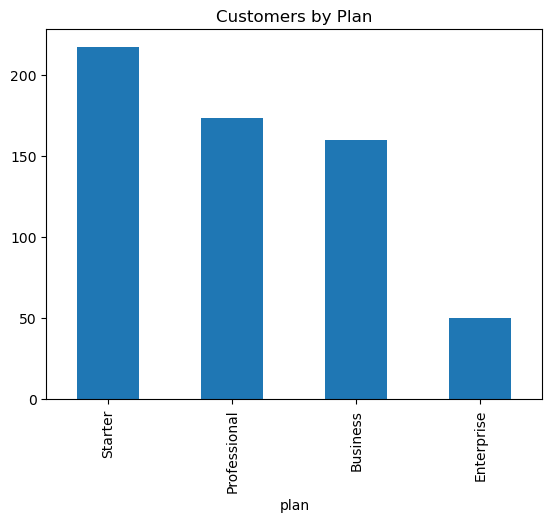

In [65]:
# Customer Distribution by plan visualization 
subscriptions['plan'].value_counts().plot(kind='bar')
plt.title('Customers by Plan')
plt.show()

In [71]:
# Which plan generates the most revenue?
subscriptions.groupby('plan')['monthly_revenue'].sum().sort_values(ascending=False)

plan
Business        208581.83
Enterprise      149249.65
Professional     85988.14
Starter          46772.96
Name: monthly_revenue, dtype: float64

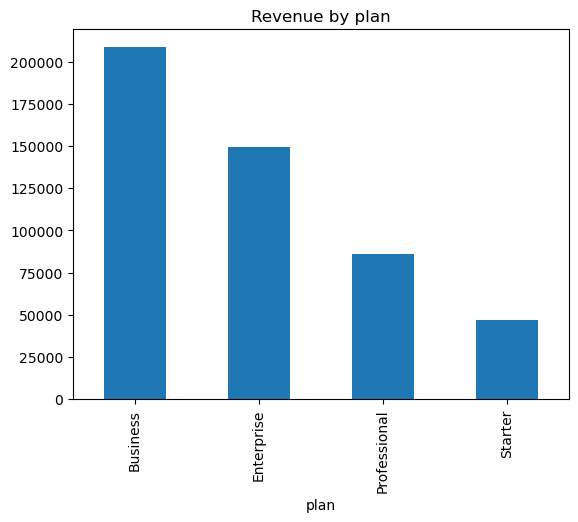

In [70]:
# Visualization
subscriptions.groupby('plan')['monthly_revenue'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Revenue by plan')
plt.show()

In [73]:
# Billing Cycle analysis
subscriptions['billing_cycle'].value_counts()

billing_cycle
Monthly    352
Annual     248
Name: count, dtype: int64

In [75]:
# Do annually customers contribute more revenue than monthly customers?
subscriptions.groupby('billing_cycle')['monthly_revenue'].sum()

billing_cycle
Annual     183658.53
Monthly    306934.05
Name: monthly_revenue, dtype: float64

In [8]:
# EDA Phase 2: Customer Segmentation Analysis
# Industry analysis
# Which industry generates the highest revenue

subscriptions.groupby('industry')['monthly_revenue'].sum()

industry
Consulting       47489.04
Education        58820.37
Finance          45936.22
Healthcare       65056.91
Legal            45126.71
Manufacturing    56880.71
Media            42016.19
Real Estate      44764.08
Retail           49484.22
Technology       35018.13
Name: monthly_revenue, dtype: float64

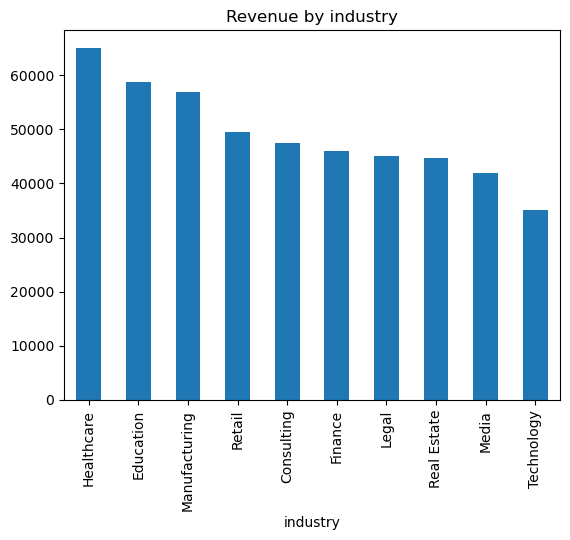

In [7]:
# Visulization

subscriptions.groupby('industry')['monthly_revenue'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Revenue by industry')
plt.show()

In [95]:
# Customer distribution by industry
subscriptions['industry'].value_counts()

industry
Education        77
Manufacturing    64
Consulting       62
Finance          61
Real Estate      61
Healthcare       61
Legal            57
Media            54
Retail           52
Technology       51
Name: count, dtype: int64

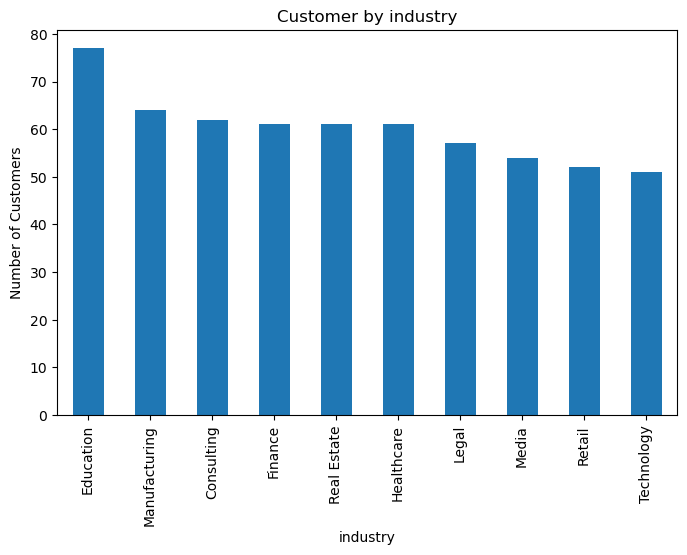

In [98]:
# Visualization
subscriptions['industry'].value_counts().plot(kind='bar',figsize=(8,5))
plt.title('Customer by industry')
plt.ylabel('Number of Customers')
plt.show()

In [109]:
# Company Size analysis
# Are enterprise customers driving revenue or are small businesses?
subscriptions['company_size'].value_counts()

company_size
11-50      176
1-10       157
51-200     141
201-500     88
500+        38
Name: count, dtype: int64

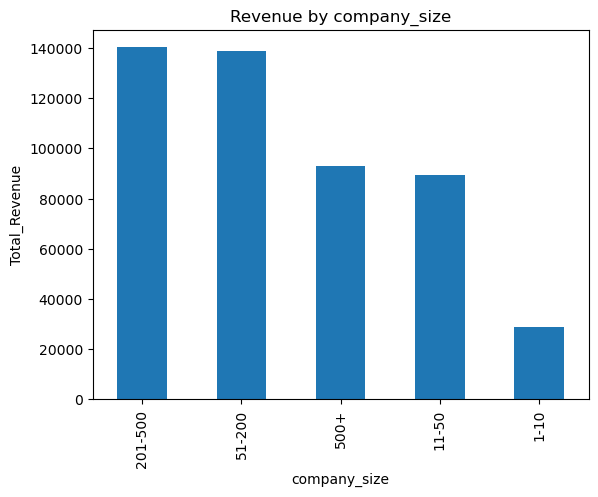

In [142]:
# Visualisation
subscriptions.groupby('company_size')['monthly_revenue'].sum().sort_values(ascending = False).plot(kind='bar')
plt.title('Revenue by company_size')
plt.ylabel('Total_Revenue')
plt.show()

In [116]:
# Region Analysis
# Which region contribute the monthly_revenue
subscriptions['region'].value_counts()

region
North America    284
Europe           162
Asia Pacific      94
Latin America     60
Name: count, dtype: int64

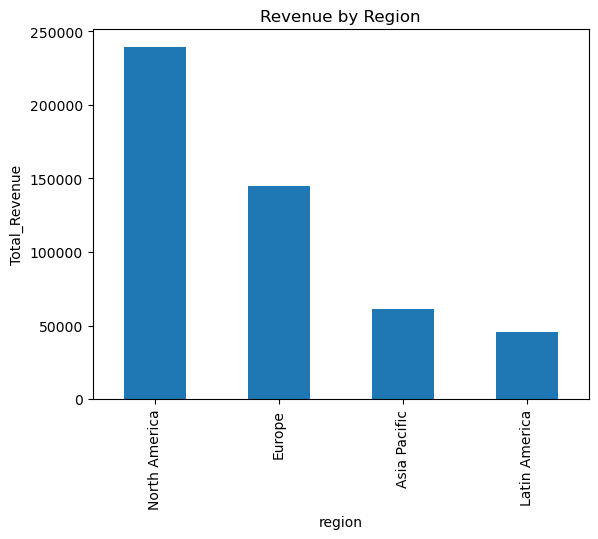

In [143]:
# Visualization
subscriptions.groupby('region')['monthly_revenue'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Revenue by Region')
plt.ylabel('Total_Revenue')
plt.show()

In [124]:
# Acquisition Channel Analysis
# Which acquisition channel bring the highest revenue customers?

subscriptions['acquisition_channel'].value_counts()

acquisition_channel
Organic Search    153
Referral          124
Paid Ads          115
Partner           100
Direct Sales       56
Social Media       52
Name: count, dtype: int64

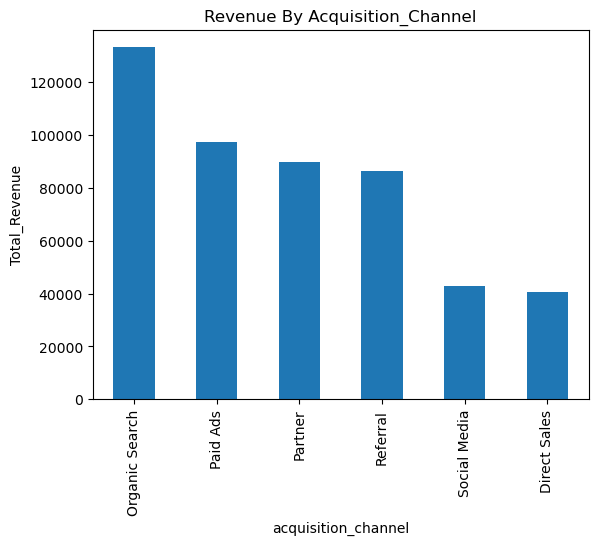

In [127]:
# Visualization
subscriptions.groupby('acquisition_channel')['monthly_revenue'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Revenue By Acquisition_Channel')
plt.ylabel('Total_Revenue')
plt.show()

In [130]:
# Seats Analysis
# Do customer with more seats genrate more revenue?
subscriptions['seats'].describe()

count    600.000000
mean      42.450000
std       51.279823
min        1.000000
25%        7.000000
50%       26.000000
75%       58.000000
max      297.000000
Name: seats, dtype: float64

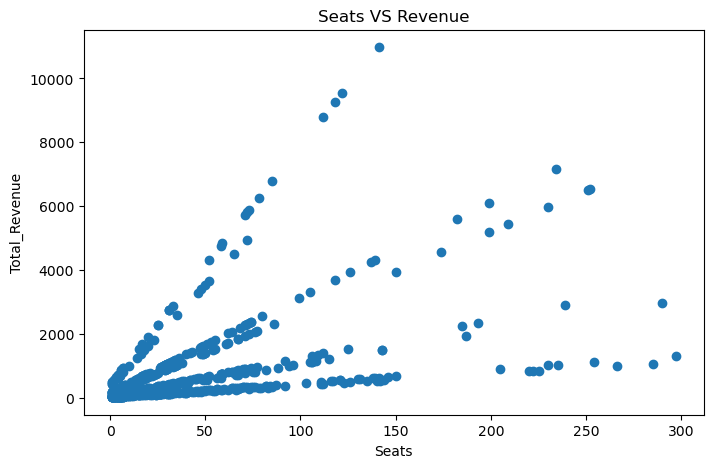

In [133]:
plt.figure(figsize =(8,5))

plt.scatter(subscriptions['seats'],subscriptions['monthly_revenue'])
plt.title('Seats VS Revenue')
plt.xlabel('Seats')
plt.ylabel('Total_Revenue')
plt.show()

In [137]:
# Are customer actively using the product?
subscriptions['feature_usage_pct'].describe()

count    600.000000
mean      40.638333
std       22.749801
min       10.000000
25%       22.750000
50%       36.000000
75%       50.000000
max       95.000000
Name: feature_usage_pct, dtype: float64

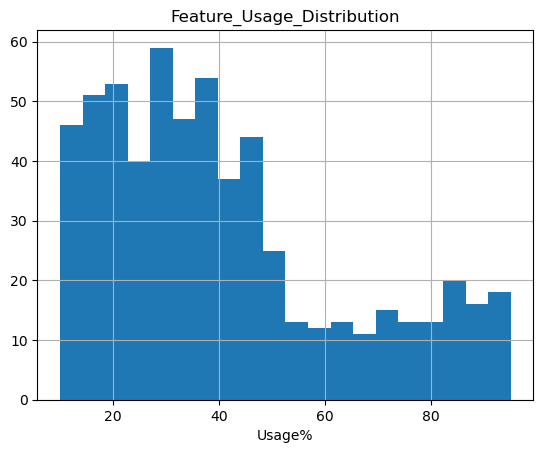

In [141]:
subscriptions['feature_usage_pct'].hist(bins=20)
plt.title('Feature_Usage_Distribution')
plt.xlabel('Usage%')
plt.show()

In [9]:
# EDA Phase 3 : Churn Analysis
# Overall churn rate

subscriptions['churned'].value_counts()

churned
Yes    313
No     287
Name: count, dtype: int64

In [19]:
churn_rate = subscriptions['churned'].value_counts(normalize=True)['Yes']*100
print(f"churn_rate:{churn_rate:.2f}%")

churn_rate:52.17%


In [24]:
# Churn by plan

churn_plan = pd.crosstab(subscriptions['plan'],subscriptions['churned'],normalize = 'index')*100
churn_plan

churned,No,Yes
plan,,
Business,58.750000,41.250000
Enterprise,78.000000,22.000000
Professional,52.023121,47.976879
Starter,29.493088,70.506912


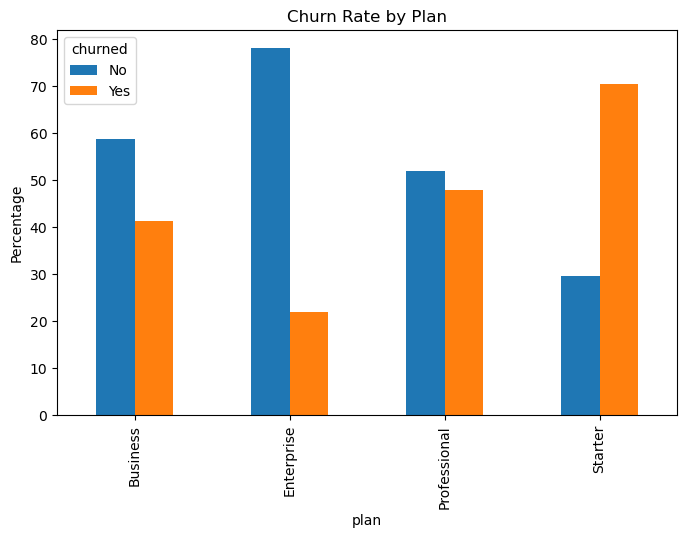

In [27]:
churn_plan.plot(kind='bar',figsize=(8,5))
plt.title('Churn Rate by Plan')
plt.ylabel('Percentage')
plt.show()

# The starter plan has the highest churn rate, indicating customers on this tier may not be receiving enough value.

In [31]:
# Churn by billing cycle
# Do annual customer churn less than monthly customers?
churn_billing_cycle = pd.crosstab(subscriptions['plan'],subscriptions['billing_cycle'],normalize = 'index')*100
churn_billing_cycle


billing_cycle,Annual,Monthly
plan,,
Business,45.625000,54.375000
Enterprise,36.000000,64.000000
Professional,42.774566,57.225434
Starter,38.248848,61.751152


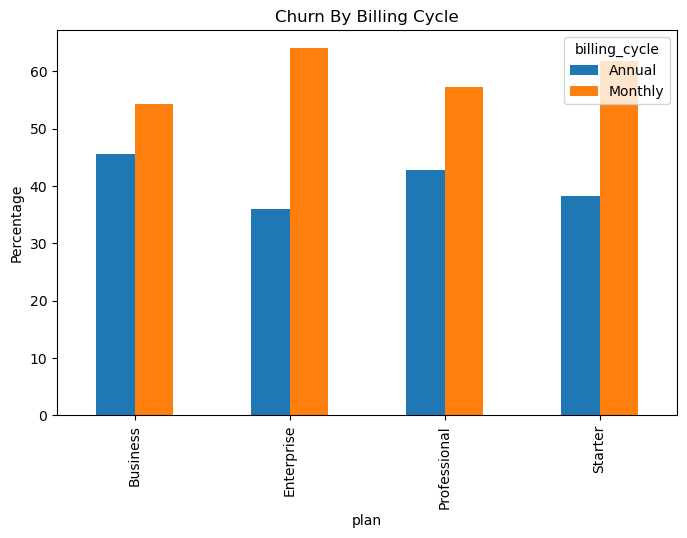

In [34]:
churn_billing_cycle.plot(kind='bar',figsize=(8,5))
plt.title('Churn By Billing Cycle')
plt.ylabel('Percentage')
plt.show()

# Annual subscribers shoe lower churn because they are more committed

In [38]:
# Churn by industry
# Which industry have the highest churn?
industry_churn = pd.crosstab(subscriptions['plan'],subscriptions['industry'],normalize = 'index')*100

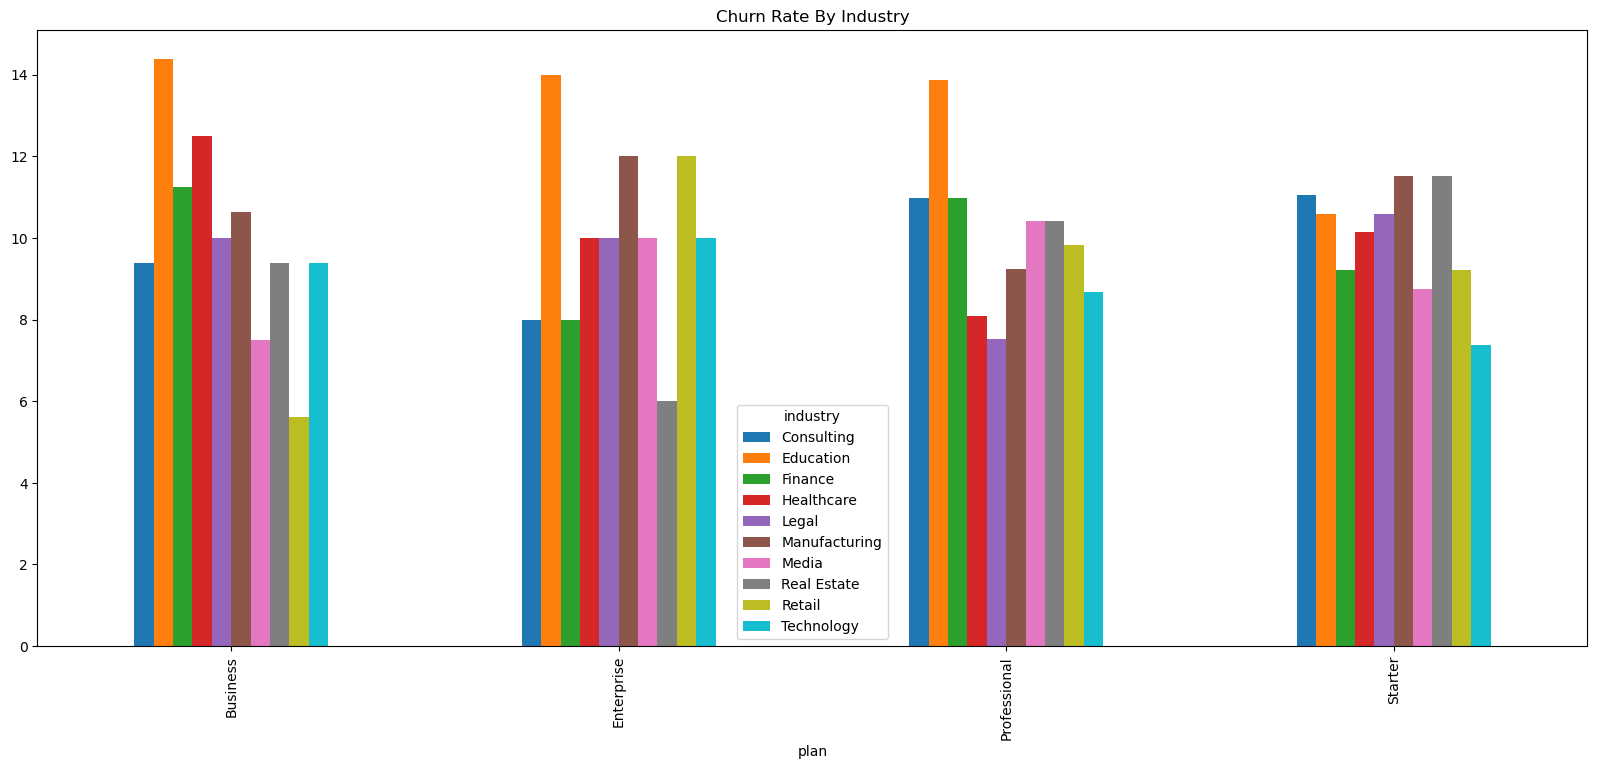

In [46]:
# Visualization
industry_churn.plot(kind='bar',figsize = (20,8))
plt.title('Churn Rate By Industry')
plt.show()

In [48]:
# Churn by company size
# Do small companies churn more than large companies?
Company_churn = pd.crosstab(subscriptions['plan'],subscriptions['company_size'],normalize = 'index')*100

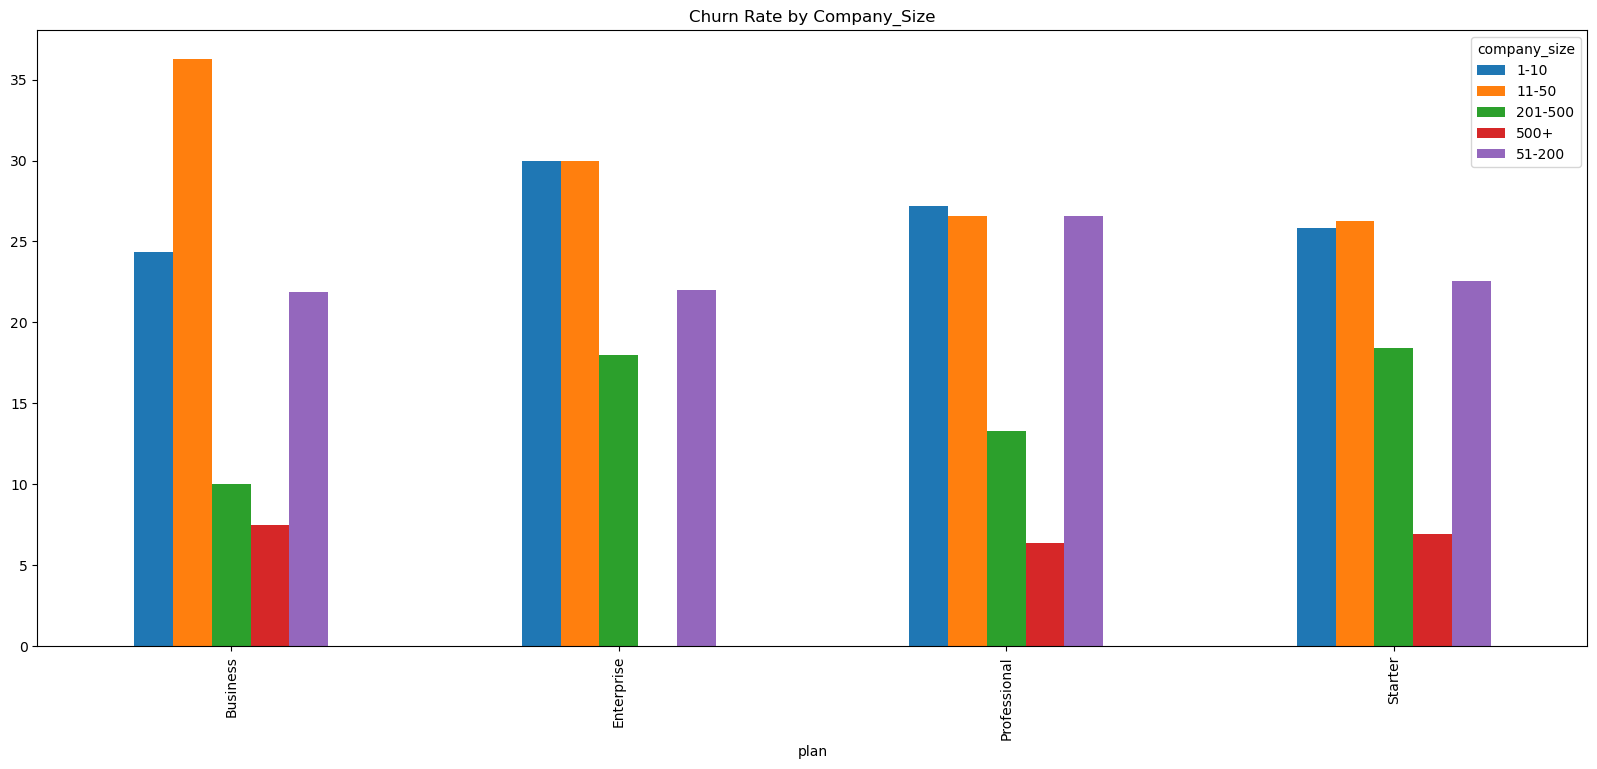

In [52]:
# Visualization
Company_churn.plot(kind='bar',figsize=(20,8))
plt.title('Churn Rate by Company_Size')
plt.show()

# Small companies churn more frequently then enterprise customers.

In [55]:
# NPS VS Churn

def nps_group(x):
    if x>=9:
        return 'Promoter'
    elif x>=7:
        return 'Passive'
    else:
        return 'Detractor'
subscriptions['nps_category']= subscriptions['nps_score'].apply(nps_group)

In [56]:
subscriptions['nps_category'].value_counts()

nps_category
Detractor    470
Passive       69
Promoter      61
Name: count, dtype: int64

In [62]:
Churn_nps_category = pd.crosstab(subscriptions['nps_category'],subscriptions['churned'],normalize = 'index')*100

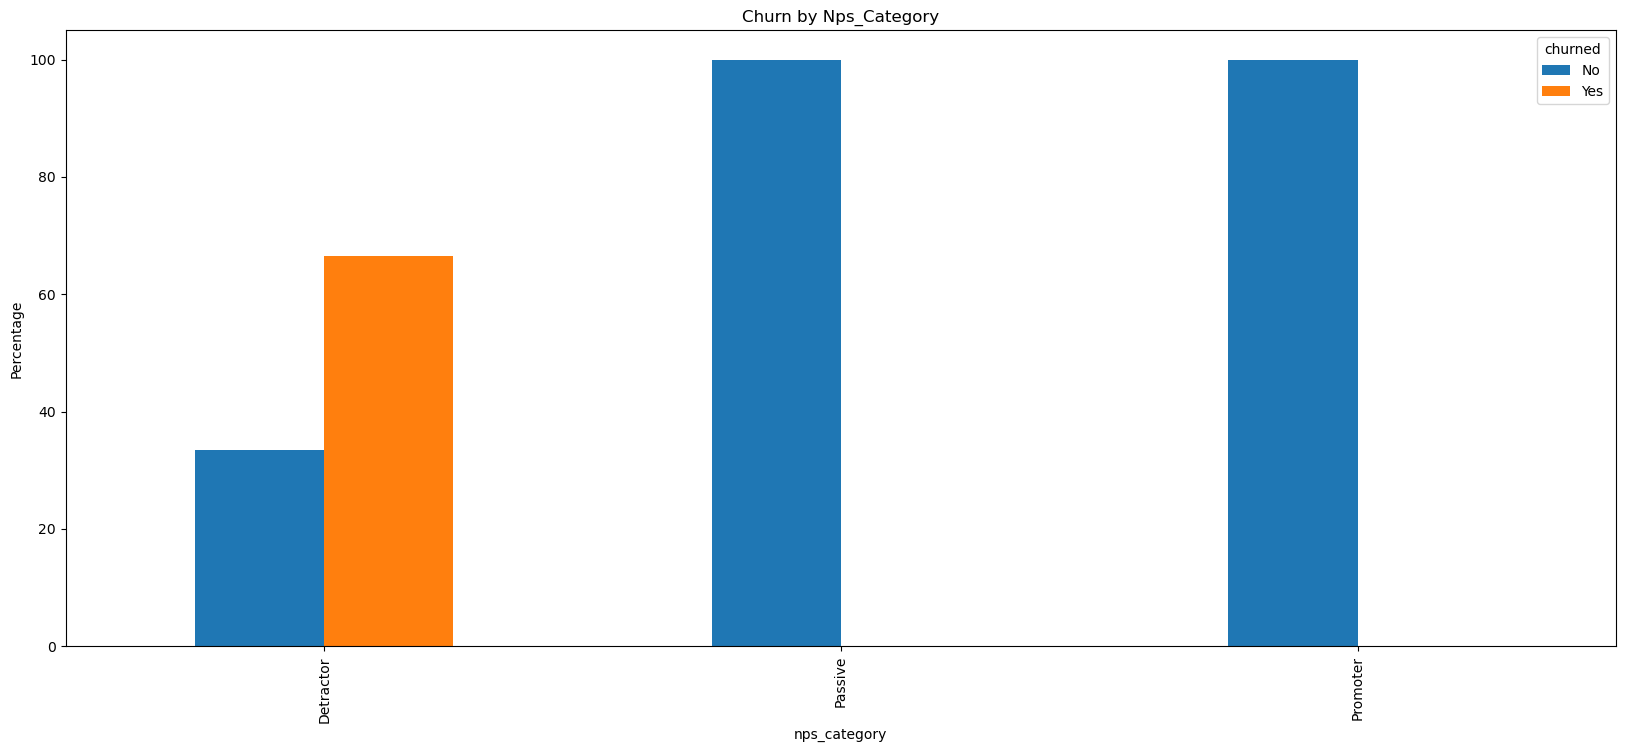

In [74]:
# Visualization
Churn_nps_category.plot(kind='bar',figsize = (20,8))
plt.title('Churn by Nps_Category')
plt.ylabel('Percentage')
plt.show()

# Detractors churn significantly more than Promoters and Passive. 

In [67]:
# Feature Usage vs Churn
# Does low product usage lead to churn?

subscriptions['usage_group'] = pd.cut(subscriptions['feature_usage_pct'],bins=[0,40,70,100],labels=['Low','Medium','High'])

In [68]:
subscriptions['usage_group'].value_counts()

usage_group
Low       358
Medium    151
High       91
Name: count, dtype: int64

In [71]:
Churn_usage_group = pd.crosstab(subscriptions['usage_group'],subscriptions['churned'],normalize = 'index')*100

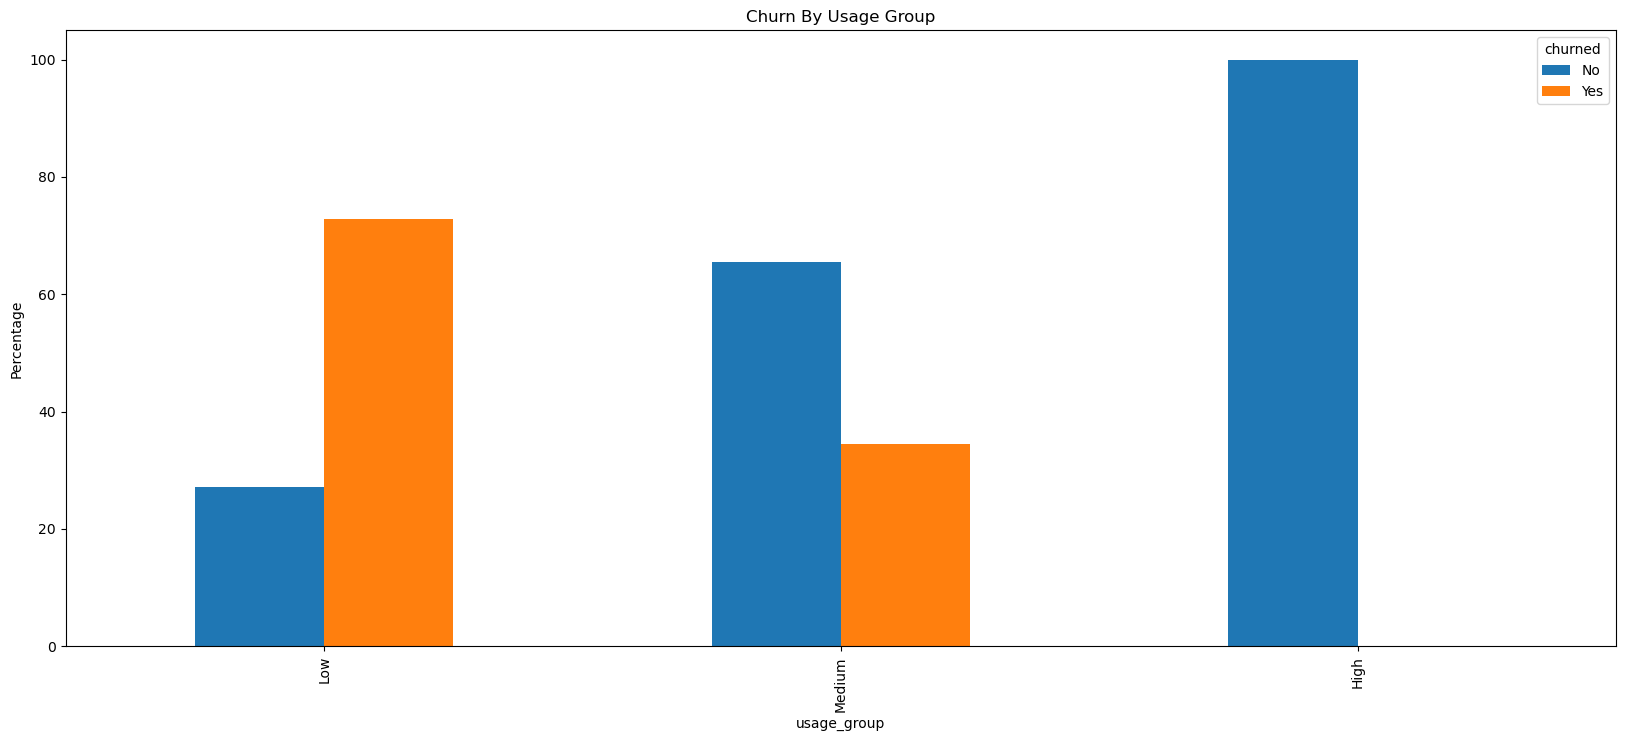

In [73]:
Churn_usage_group.plot(kind='bar',figsize = (20,8))
plt.title('Churn By Usage Group')
plt.ylabel('Percentage')
plt.show()

# Customer with low products usage exhibit significantly higher churn rates than highly engaged users.

In [75]:
# Support ticket vs churn 
# Do customers with many support issues churn rate?

subscriptions.groupby('churned')['support_tickets_12mo'].mean()

churned
No     5.501742
Yes    7.376997
Name: support_tickets_12mo, dtype: float64

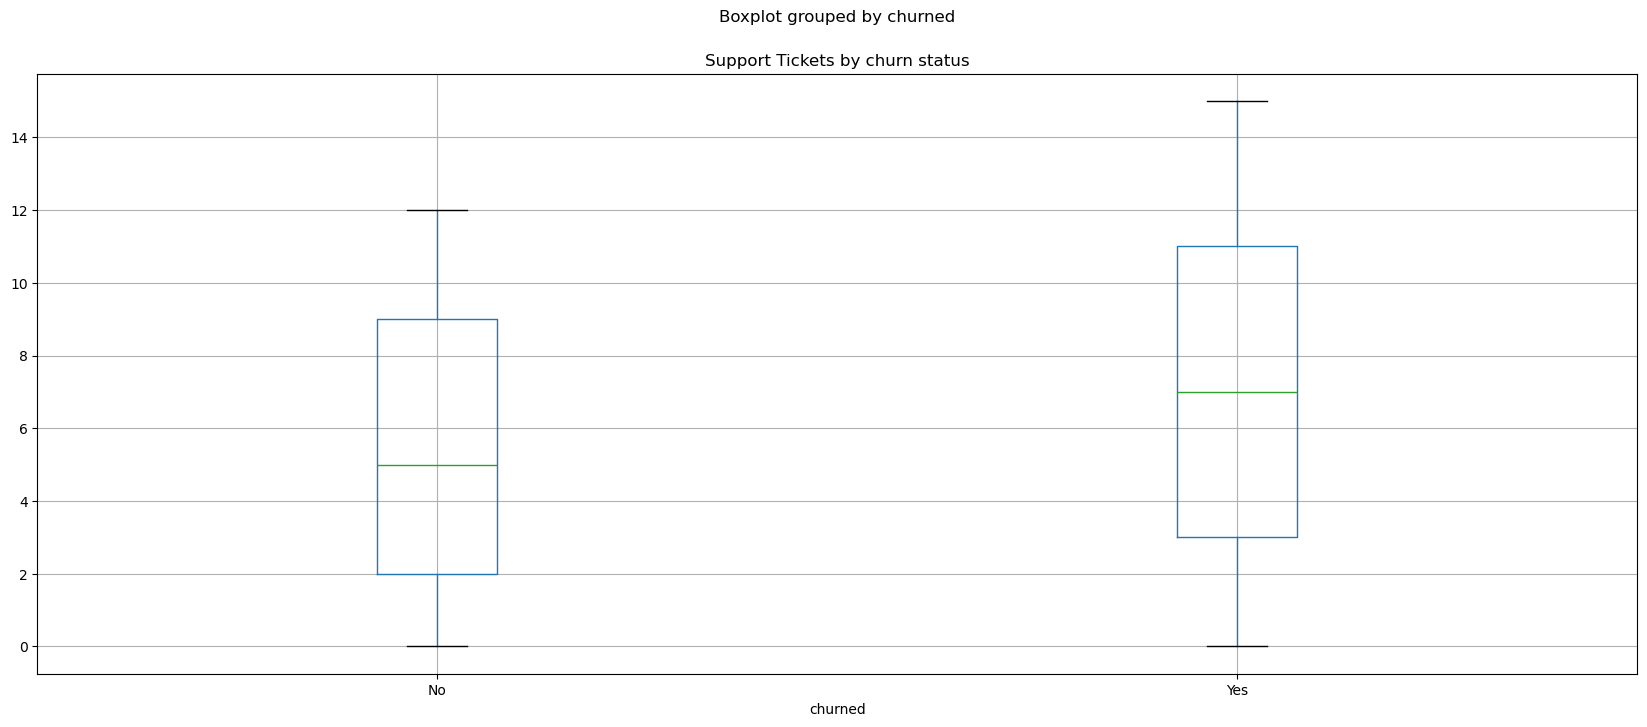

In [77]:
# Visualization
subscriptions.boxplot(column = 'support_tickets_12mo',by = 'churned', figsize = (20,8))
plt.title('Support Tickets by churn status')
plt.show()

# Churned customers submitted more support tickets on average, suggesting product fiction may contribute to customer loss.

In [82]:
# Churned Reasons
churned_customer = subscriptions[subscriptions['churned'] == 'Yes']
churned_customer['churn_reason'].value_counts()

churn_reason
Budget Cuts            53
Price Too High         51
Company Closed         48
Poor Support           42
No Longer Needed       41
Missing Features       40
Switched Competitor    38
Name: count, dtype: int64

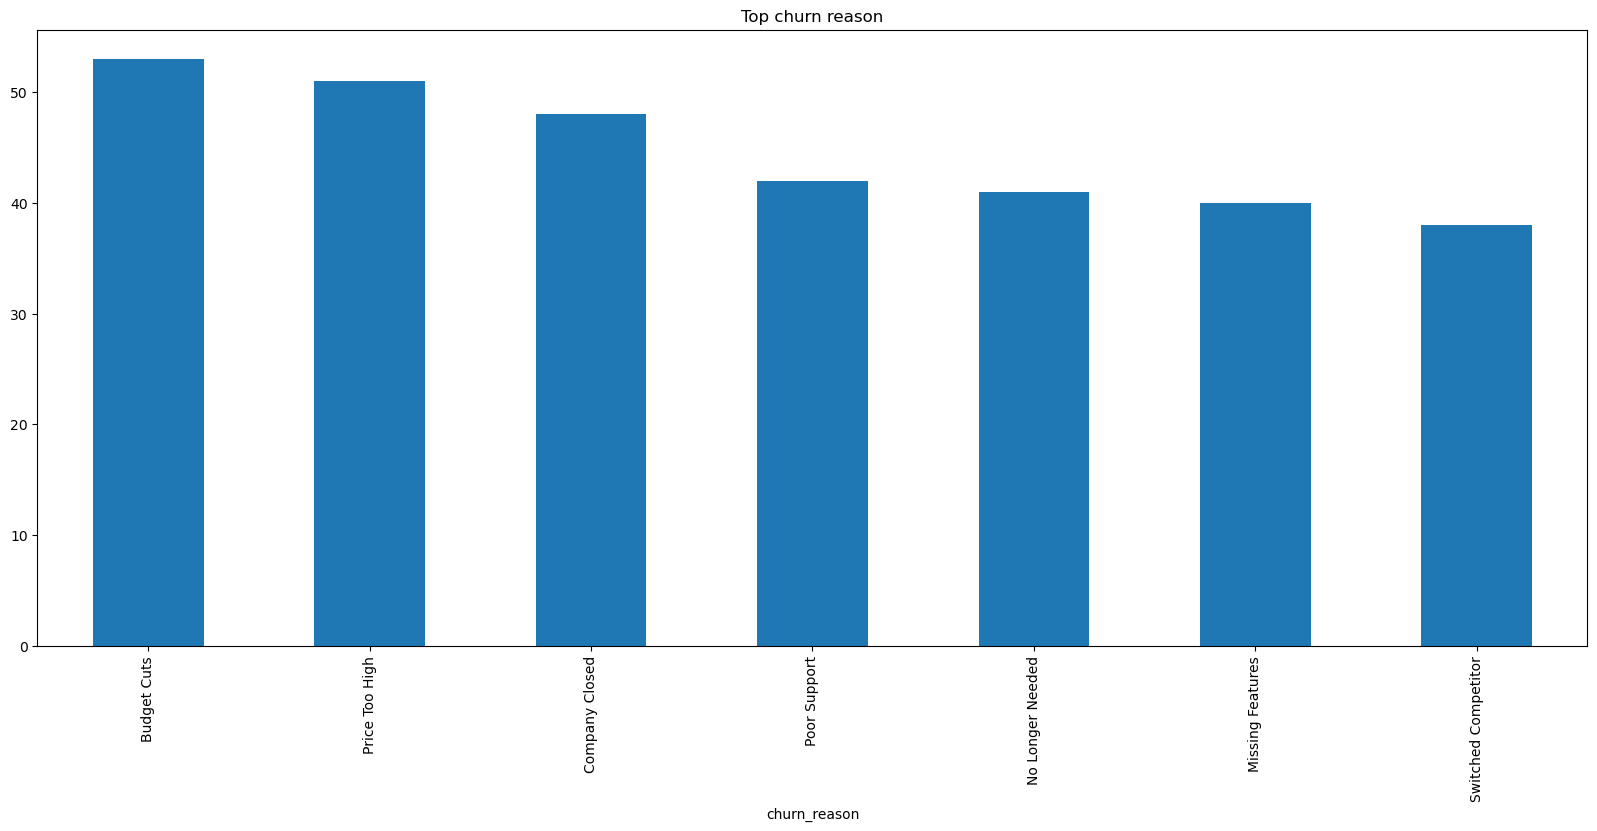

In [85]:
# Visualizations

churned_customer['churn_reason'].value_counts().plot(kind='bar',figsize = (20,8))
plt.title('Top churn reason')
plt.show()

In [86]:
# Phase 4: Revenue & Growth Analysis
monthly_revenue.head()

,month,total_active_customers,new_customers,churned_customers,monthly_churn_rate_pct,total_mrr,avg_revenue_per_customer,customer_acquisition_cost
0,2022-01,0,5,0,0.00,0.00,0.00,164.92
1,2022-02,5,10,1,20.00,7333.07,1466.61,189.21
2,2022-03,14,13,0,0.00,12301.16,878.65,139.49
3,2022-04,28,11,3,10.71,24798.76,885.67,259.09
4,2022-05,35,11,1,2.86,29091.88,831.20,152.96


In [87]:
monthly_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   total_active_customers     48 non-null     int64  
 2   new_customers              48 non-null     int64  
 3   churned_customers          48 non-null     int64  
 4   monthly_churn_rate_pct     48 non-null     float64
 5   total_mrr                  48 non-null     float64
 6   avg_revenue_per_customer   48 non-null     float64
 7   customer_acquisition_cost  48 non-null     float64
dtypes: float64(4), int64(3), object(1)
memory usage: 3.1+ KB


In [88]:
monthly_revenue.describe()

,total_active_customers,new_customers,churned_customers,monthly_churn_rate_pct,total_mrr,avg_revenue_per_customer,customer_acquisition_cost
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,167.416667,12.500000,6.520833,4.518958,174888.413958,1010.218958,200.040625
std,85.274234,3.339002,3.414547,3.251457,92619.227429,175.723630,52.694255
min,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,122.990000
25%,104.000000,10.750000,4.000000,3.007500,102605.177500,1009.865000,150.267500
50%,184.500000,13.000000,7.000000,3.755000,190681.445000,1030.135000,197.250000
75%,241.750000,14.250000,8.250000,4.552500,262177.912500,1072.027500,249.187500
max,281.000000,19.000000,17.000000,20.000000,292628.610000,1466.610000,279.590000


In [89]:
# MRR Growth
# How has monthly recurring revenue change over time?
monthly_revenue[['month','total_mrr']]

,month,total_mrr
0,2022-01,0.00
1,2022-02,7333.07
2,2022-03,12301.16
3,2022-04,24798.76
4,2022-05,29091.88
5,2022-06,38919.93
6,2022-07,45097.72
7,2022-08,54140.41
8,2022-09,65198.00
9,2022-10,86824.16


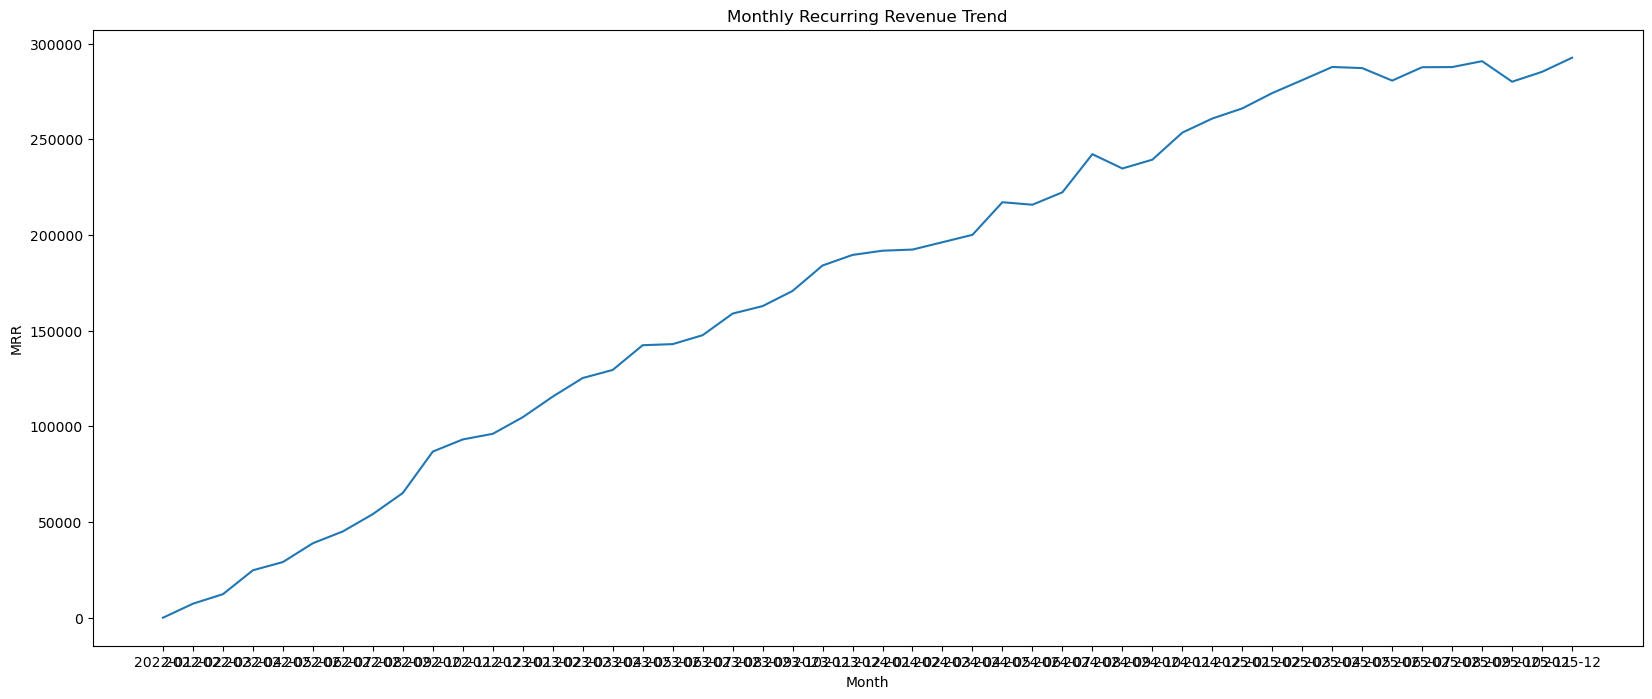

In [93]:
plt.figure(figsize=(20,8))
plt.plot(monthly_revenue['month'],monthly_revenue['total_mrr'])
plt.title('Monthly Recurring Revenue Trend')
plt.xlabel('Month')
plt.ylabel('MRR')
plt.show()

# Healthy Growth in MRR

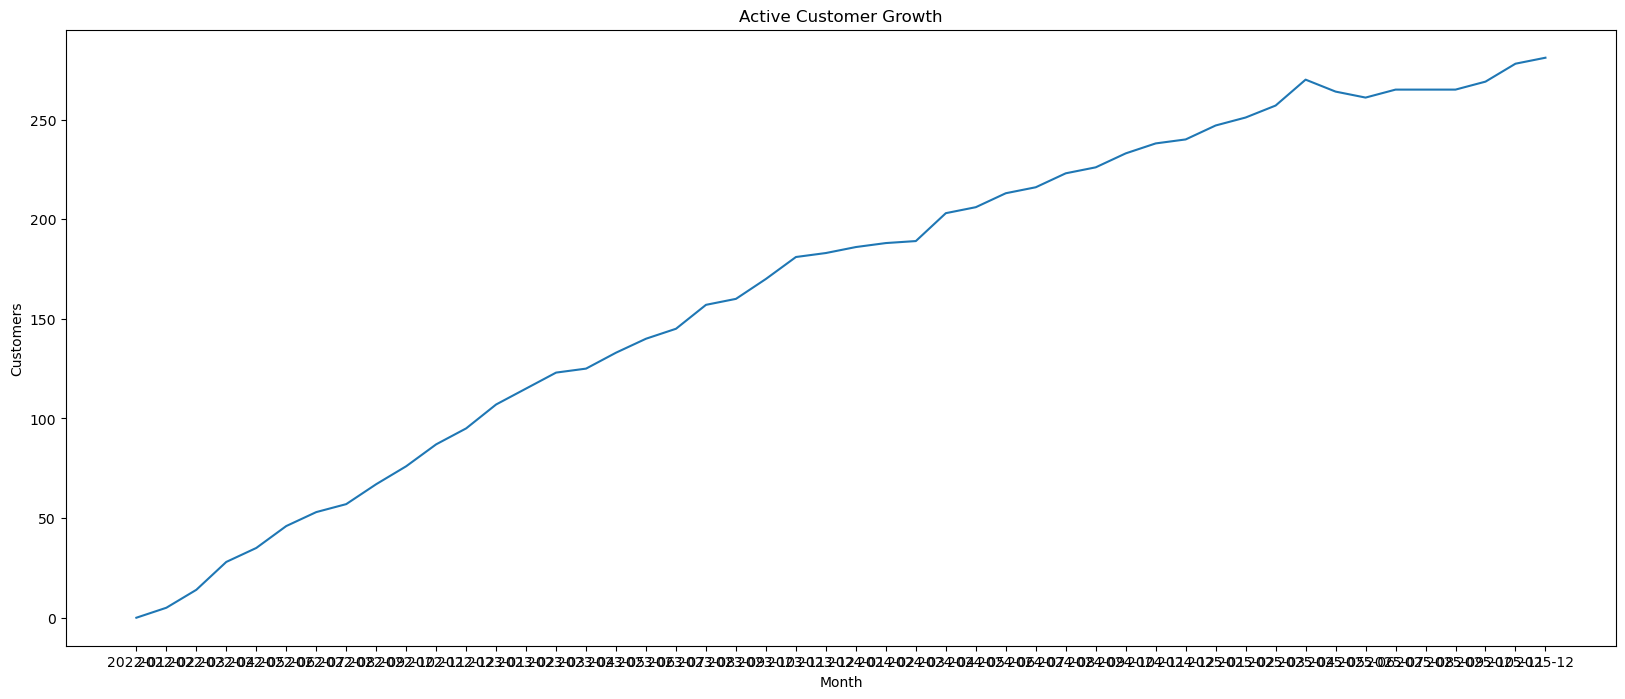

In [99]:
# Customers growth trend
plt.figure(figsize = (20,8))

plt.plot(monthly_revenue['month'], monthly_revenue['total_active_customers'])
plt.title('Active Customer Growth')
plt.xlabel('Month')
plt.ylabel('Customers')
plt.show()

# Healthy active customer growth over the period 

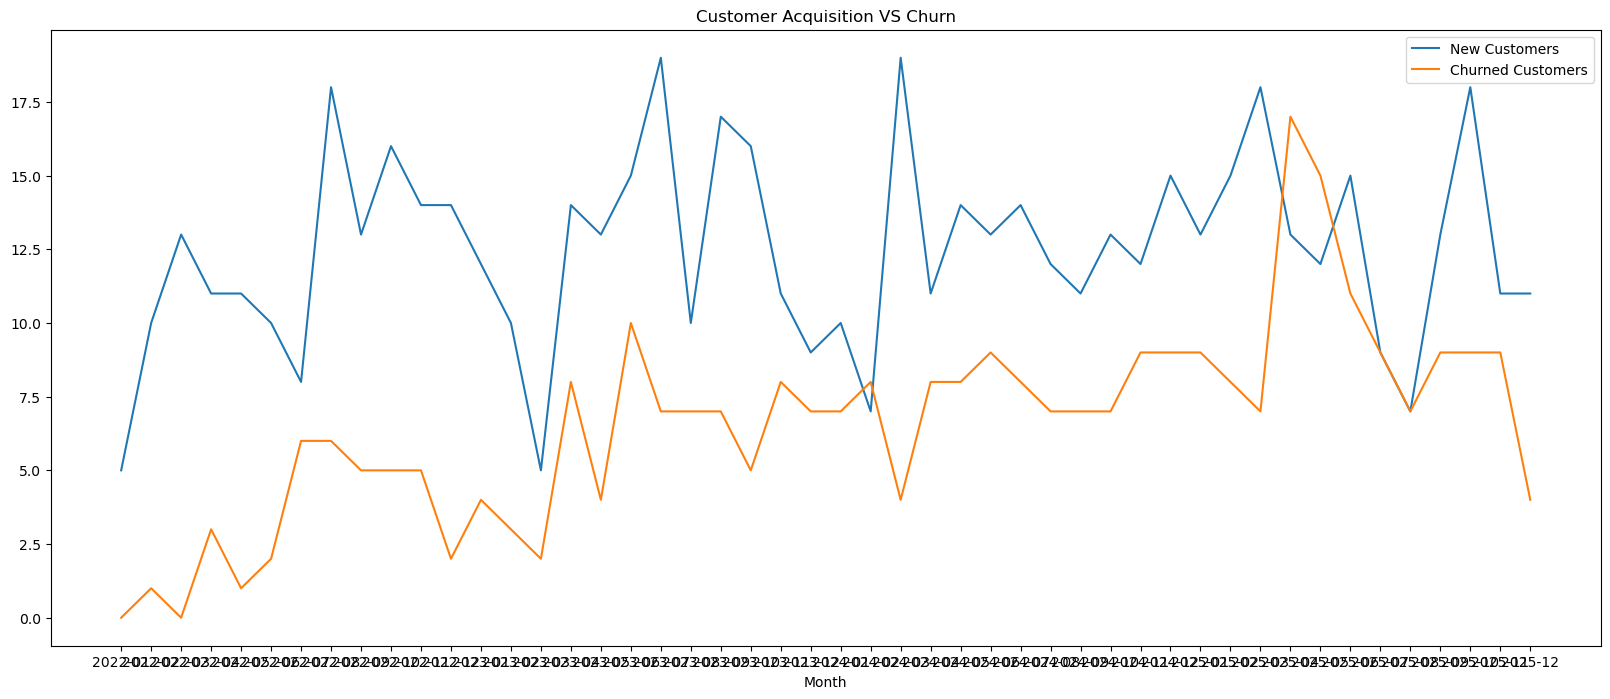

In [106]:
# New Customer VS Churned Customer
# Are we acquiring customers faster than we are losing them?

plt.figure(figsize = (20,8))

plt.plot(monthly_revenue['month'],monthly_revenue['new_customers'],label = 'New Customers')
plt.plot(monthly_revenue['month'],monthly_revenue['churned_customers'],label = 'Churned Customers')
plt.legend()
plt.title('Customer Acquisition VS Churn')
plt.xlabel('Month')
plt.show()


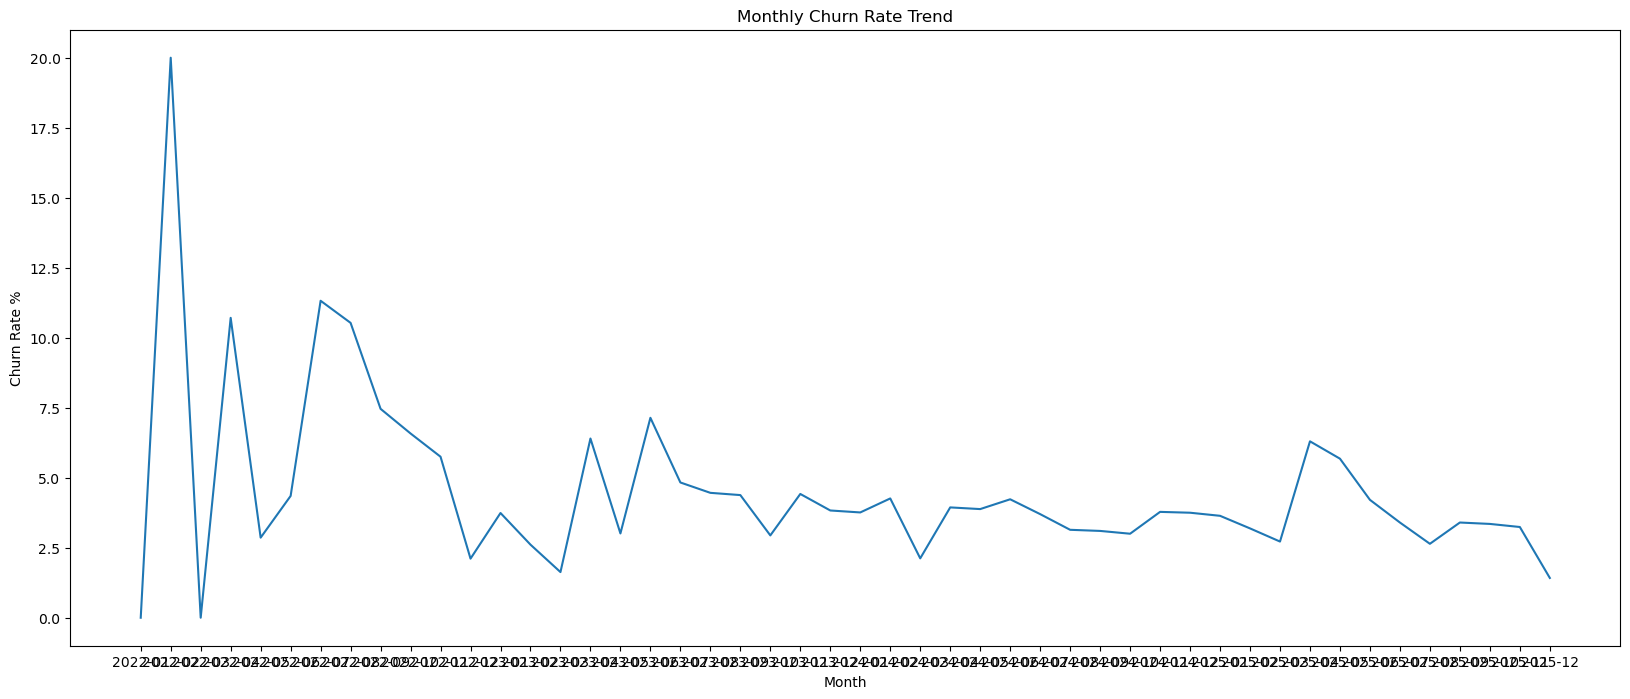

In [110]:
# Monthly Churn rate trend
# is churn improving or worsening over time
plt.figure(figsize = (20,8))

plt.plot(monthly_revenue['month'],monthly_revenue['monthly_churn_rate_pct'])
plt.title('Monthly Churn Rate Trend')
plt.xlabel('Month')
plt.ylabel('Churn Rate %')
plt.show()

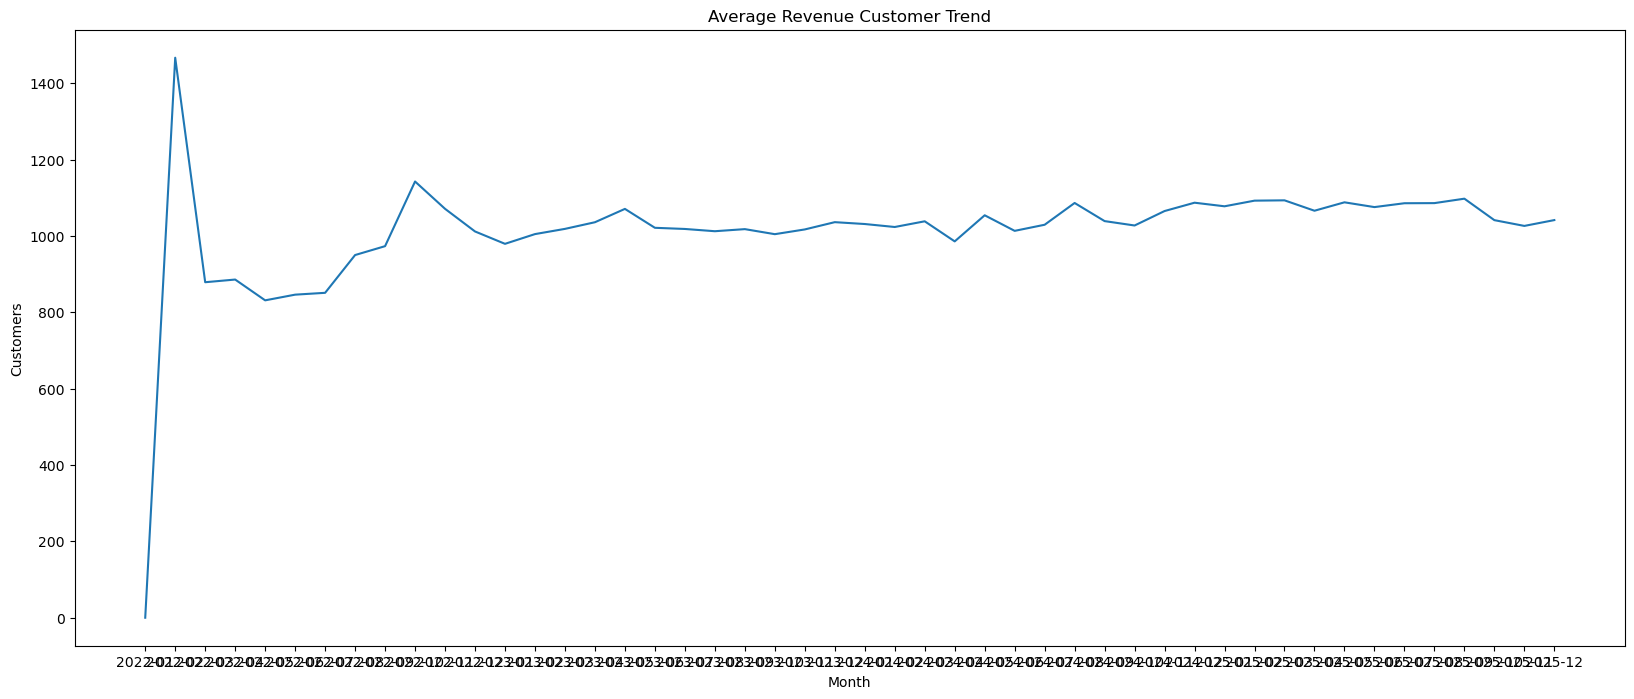

In [113]:
# Average revenue per customer trend
plt.figure(figsize = (20,8))

plt.plot(monthly_revenue['month'],monthly_revenue['avg_revenue_per_customer'])
plt.title('Average Revenue Customer Trend')
plt.xlabel('Month')
plt.ylabel('Customers')
plt.show()

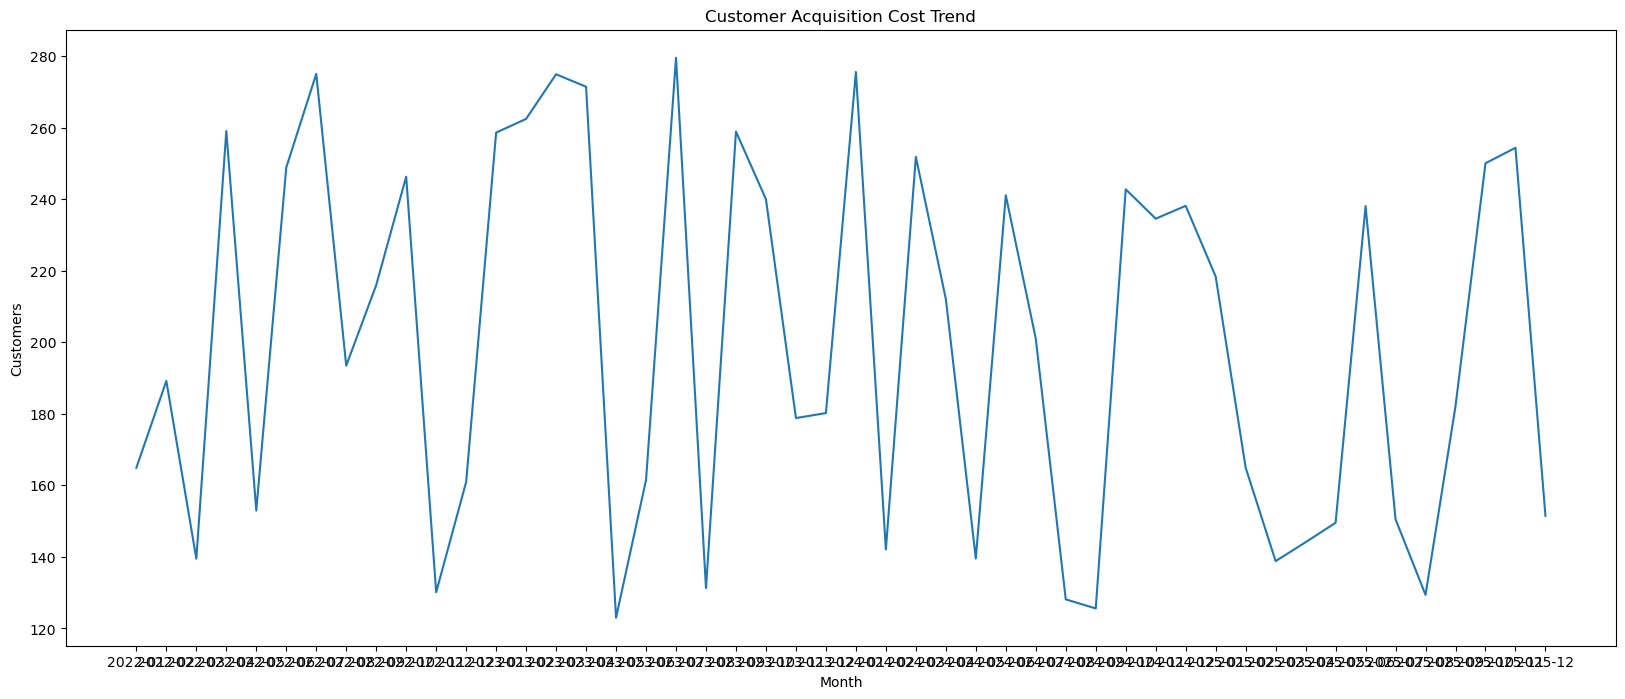

In [120]:
# Customer Aquisition Cost (CAC)
# it is becoming more expensive to acuire customers?

plt.figure(figsize = (20,8))

plt.plot(monthly_revenue['month'],monthly_revenue['customer_acquisition_cost'])
plt.title('Customer Acquisition Cost Trend')
plt.xlabel('Month')
plt.ylabel('Customers')
plt.show()

In [123]:
# Revenue Growth %
# Which month experienced the strongest growth?

monthly_revenue['mrr_growth_pct'] = (monthly_revenue['total_mrr'].pct_change()*100)

In [125]:
monthly_revenue[['month','total_mrr','mrr_growth_pct']]

,month,total_mrr,mrr_growth_pct
0,2022-01,0.00,NaN
1,2022-02,7333.07,inf
2,2022-03,12301.16,67.749115
3,2022-04,24798.76,101.596923
4,2022-05,29091.88,17.311833
5,2022-06,38919.93,33.782794
6,2022-07,45097.72,15.873076
7,2022-08,54140.41,20.051324
8,2022-09,65198.00,20.423913
9,2022-10,86824.16,33.169975


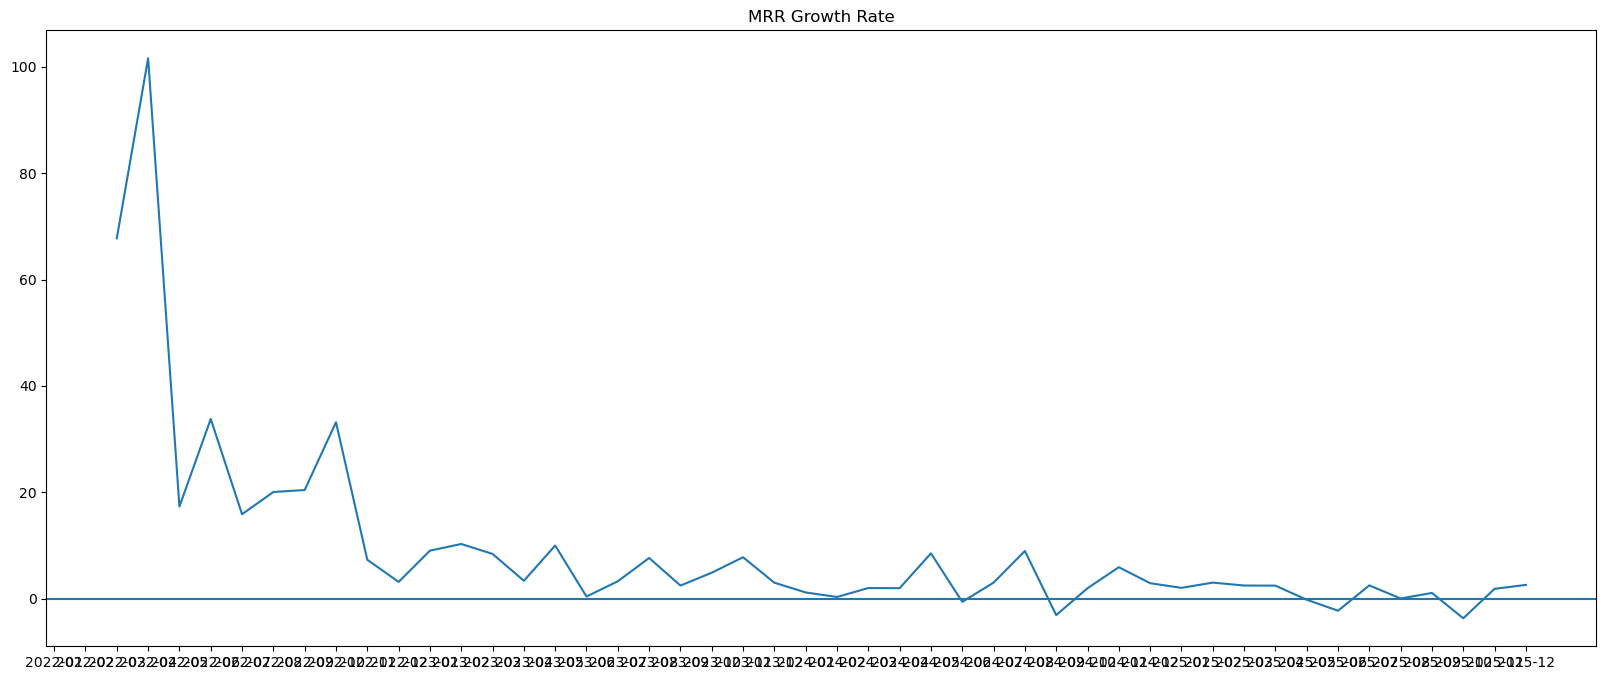

In [129]:
# Visualization

plt.figure(figsize = (20,8))

plt.plot(monthly_revenue['month'],monthly_revenue['mrr_growth_pct'])
plt.axhline(0)
plt.title('MRR Growth Rate')
plt.show()

In [133]:
# Net customer growth
# is the business gaining or lossing customers overall?
monthly_revenue['net_customer_growth'] = monthly_revenue['new_customers']-monthly_revenue['churned_customers']

In [135]:
monthly_revenue[['month','net_customer_growth']]

,month,net_customer_growth
0,2022-01,5
1,2022-02,9
2,2022-03,13
3,2022-04,8
4,2022-05,10
5,2022-06,8
6,2022-07,2
7,2022-08,12
8,2022-09,8
9,2022-10,11


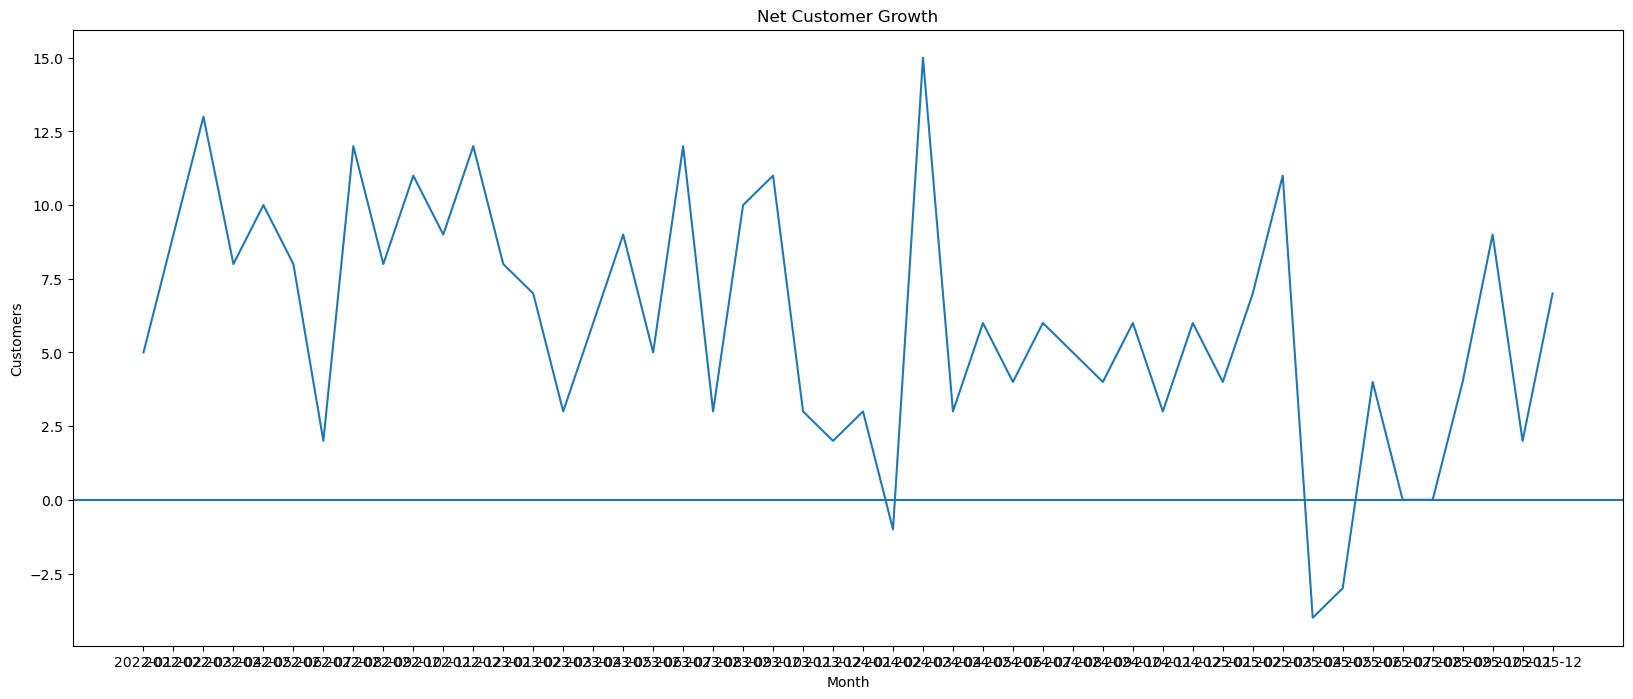

In [139]:
plt.figure(figsize = (20,8))

plt.plot(monthly_revenue['month'],monthly_revenue['net_customer_growth'])
plt.axhline(0)
plt.title('Net Customer Growth')
plt.ylabel('Customers')
plt.xlabel('Month')
plt.show()

In [144]:
print("Latest MRR:", monthly_revenue['total_mrr'].iloc[-1])
print("Latest Customers:", monthly_revenue['total_active_customers'].iloc[-1])
print("Latest Churn Rate:", monthly_revenue['monthly_churn_rate_pct'].iloc[-1])
print("Latest ARPU:", monthly_revenue['avg_revenue_per_customer'].iloc[-1])
print("Latest CAC:", monthly_revenue['customer_acquisition_cost'].iloc[-1])


Latest MRR: 292628.61
Latest Customers: 281
Latest Churn Rate: 1.42
Latest ARPU: 1041.38
Latest CAC: 151.47


In [145]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [147]:
from sqlalchemy import create_engine

# Step1 Connect to postgreSQL
# Replace placeholders with your actual details
username = "postgres"   #default users
password = "Deepak9310"  #the password you set during installation
host = "localhost"        #if runninf locally
port = "5432"             #default postgresql port
database = "SaaS_Analysis"  #the database you created in pgadmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

#step2 load dataframe into postgreSql
#choose any table name
subscriptions.to_sql(name = "subscriptions", con=engine, if_exists = "replace",index=False)
monthly_revenue.to_sql(name = "monthly_revenue", con=engine, if_exists = "replace",index=False)

print("All tables loaded successfully!")

All tables loaded successfully!


In [148]:
from IPython.display import FileLink

# Save the file
subscriptions.to_csv('subscriptions_df.csv', index=False)
monthly_revenue.to_csv('monthly_revenue_df.csv', index=False)

# Create clickable download link
display(FileLink('subscriptions_df.csv'))
display(FileLink('monthly_revenue_df.csv'))

C:\Users\Deepanshu\subscriptions_df.csv

C:\Users\Deepanshu\monthly_revenue_df.csv